# Stage modélisation système Hamiltonien 
## Première approche


On pose $p := (p_x , p_y)$ le momentum à la croisé d'un champ éléctrique et magnétique. La variation du momentum s'écrit: 
$$
\begin{equation}
\frac{dp}{dt} = eE + \frac{e}{c} \left[\frac{\partial \varepsilon (p)}{\partial p}, \ B\right] 
\end{equation}
\tag{1}
$$
Où :
- $e$ est la charge de l'électron
- $E$ est le champ électrique
- $c$ la vitesse de la lumière (prendre 1)
- $\varepsilon(p)$ est la bande de dispersion tel que $\varepsilon(p) = \sqrt{M^2 + v_F^2 p^2}$ (Bande dispersion of massive Dirac fermions)
- $B$ le champ magnétique

Le problème (1) peut se réécrire sous la forme des équations Hamiltonienne suivante:
$$
\begin{equation}
    \begin{cases}
    \dfrac{dp_x}{dt} = \dfrac{\partial \mathcal{H}}{\partial p_y} \\
    \dfrac{dp_y}{dt} = -\dfrac{\partial \mathcal{H}}{\partial p_x}
    \end{cases}
\end{equation}
\tag{2}
$$
Avec $\mathcal{H}(p_x, \ p_y) := \dfrac{eB}{c} \mathcal{W} = \dfrac{eB}{c} \left[\varepsilon(p) + v_d p_y \right] $
et où l'on note $\mathcal{W}$ l'énergie totale et $v_d$ le "drift velocity" de sorte que $v_d = \dfrac{cE}{B}$.

Étudions $\mathscr{H} : t \longmapsto \mathcal{H}(p_x, \ p_y)$
$$ 
\begin{align*}
\dfrac{d\mathscr{H}}{dt} &= \dfrac{\partial \mathcal{H}}{\partial p_x}\dfrac{ dp_x}{dt} + \dfrac{\partial \mathcal{H}}{\partial p_y}\dfrac{ dp_y}{dt} \\
                         &\overset{(2)}{=} \dfrac{\partial \mathcal{H}}{\partial p_x} \dfrac{\partial \mathcal{H}}{\partial p_y} - \dfrac{\partial \mathcal{H}}{\partial p_y} \dfrac{\partial \mathcal{H}}{\partial p_x} \\ 
                         &= 0
\end{align*}
$$

Donc l'Hamiltonien ne vari pas au cours du temps.
Etudions le comportement à l'aide de quelques schémas pour que l'on puisse se faire une idée.

### Schéma Euler Explicite

En partant de (2) on va écrire le schéma explicite:
On calcule $\dfrac{\partial \mathcal{H}}{\partial p_x}$ (resp. $\dfrac{\partial \mathcal{H}}{\partial p_y}$ ) qui vaut $\dfrac{eB v_F^2 p_x}{c\varepsilon(p)}$ (resp. $\dfrac{eB}{c} \left( \dfrac{v_F^2 p_y}{\varepsilon(p)}+ v_d\right)$). 

<!-- Le schéma s'écrit (a corriger j'avais fait une erreur): 
$$ P^{n+1} = \left(1 + \dfrac{\Delta t \ e B \ v_F^2}{c\ \varepsilon(p)} \right) \times P^n$$ -->

Pour simplifier, regardons le cas simple où $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$
Alors $\dfrac{\partial \mathcal{H}}{\partial p_x}$ (resp. $\dfrac{\partial \mathcal{H}}{\partial p_y}$ ) vaut $p_x$ (resp. $p_y$)
Le schéma s'écrit : 
$$
\begin{bmatrix}
p_x^{n+1} \\
p_y^{n+1} \\
\end{bmatrix} 
=
\begin{bmatrix}
1 & \Delta t \\
-\Delta t & 1 \\
\end{bmatrix}
\times 
\begin{bmatrix}
p_x^n \\
p_y^n
\end{bmatrix}
$$

In [2]:
# Packages ------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pyhamsys import HamSys, solve_ivp_sympext, Parameters
import time

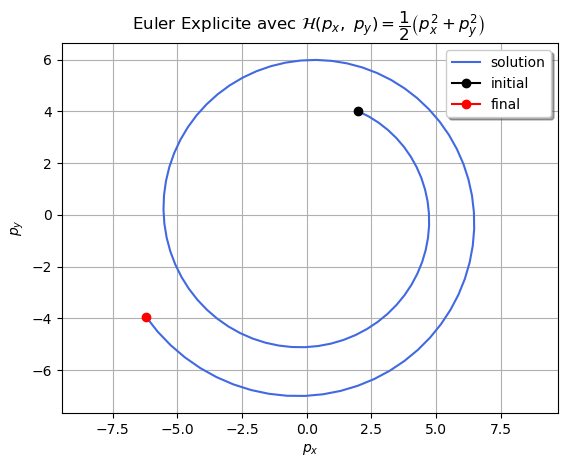

In [3]:
# Euler explicite -----------------------------
def EE_jouet(deltaT, T, P):
    Iteration_matrix = [[1, deltaT], [-deltaT, 1]]
    P_trajectory = [P]
    t = 0
    while ( t + deltaT < T):
        P = Iteration_matrix @ P
        t += deltaT
        P_trajectory.append(P)
    deltaT = T - t
    P = Iteration_matrix @ P
    return np.array(P_trajectory)
# -----------------------------------------------
p_x, p_y = 2, 4
P = np.array([p_x, p_y])
deltaT = 0.1
T = 10
P_trajectory = EE_jouet(deltaT, T, P)

plt.plot(P_trajectory[:, 0], P_trajectory[:,1], color='royalblue',label='solution')
plt.plot(P_trajectory[0,0], P_trajectory[0, 1], color='black', marker='o', label='initial')
plt.plot(P_trajectory[-1,0], P_trajectory[-1, 1], color='red', marker='o', label='final')

plt.legend(shadow=True)
plt.title(r'Euler Explicite avec $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$ ')
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.axis('equal')
plt.grid()
plt.show()

### Euler Implicite
De façon similaire on obtient le schéma implicite:
$$
\begin{align*}
\begin{bmatrix}
1 & -\Delta t \\
\Delta t & 1 \\
\end{bmatrix}
\times 
\begin{bmatrix}
p_x^{n+1} \\
p_y^{n+1} \\
\end{bmatrix} 
&=&
\begin{bmatrix}
p_x^n \\
p_y^n
\end{bmatrix} \\
P^{n+1} &=& \dfrac{1}{1 + (\Delta t)^2} 
\begin{bmatrix}
1 & \Delta t \\
-\Delta t & 1 \\
\end{bmatrix}
 \times P^n
\end{align*}
$$

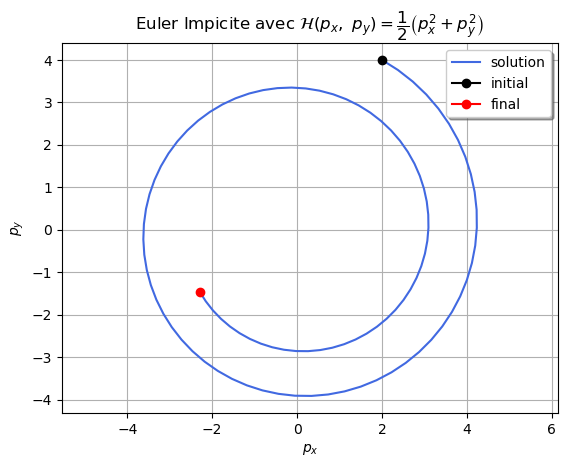

In [4]:
# Euler implicite -----------------------------
def EI_jouet(deltaT, T, P):
    Iteration_matrix = [[1/(1 + deltaT**2), deltaT/(1 + deltaT**2)], [-deltaT/(1 + deltaT**2), 1/(1 + deltaT**2)]]
    P_trajectory = [P]
    t = 0
    while ( t + deltaT < T):
        P = Iteration_matrix @ P
        t += deltaT
        P_trajectory.append(P)
    deltaT = T - t
    P = Iteration_matrix @ P
    return np.array(P_trajectory)
# -----------------------------------------------
p_x, p_y = 2, 4
P = np.array([p_x, p_y])
deltaT = 0.1
T = 10
P_trajectory = EI_jouet(deltaT, T, P)

plt.plot(P_trajectory[:, 0], P_trajectory[:,1], color='royalblue',label='solution')
plt.plot(P_trajectory[0,0], P_trajectory[0, 1], color='black', marker='o', label='initial')
plt.plot(P_trajectory[-1,0], P_trajectory[-1, 1], color='red', marker='o', label='final')

plt.legend(shadow=True)
plt.title(r'Euler Impicite avec $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$ ')
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.axis('equal')
plt.grid()
plt.show()

### Euler Symplectique
On code le schéma suivant:
$$
\begin{cases}
\begin{align*}
x_{n+1} &=& x_n + h \partial_x \mathcal{H}(x_n, y_{n+1}) \\
y_{n+1} &=& y_n + h \partial_y \mathcal{H}(x_n, y_{n+1}) 
\end{align*}
\end{cases}
$$
On repart de notre problème $\mathcal{H}(p_x^n, \ p_y^{n+1}) = \dfrac{1}{2}\left((p_x^{n})^2 + (p_y^{n+1})^2\right)$ avec $\partial_x \mathcal{H} = p_x^n$ et $  \partial_y \mathcal{H} = p_y^{n+1}$. \\
Puisque notre problème vérifie:
$$
\begin{cases}
\begin{align*}
\partial_t p_x &=& \partial_y H \\
\partial_t p_y &=& -\partial_x H
\end{align*}
\end{cases}
$$
On obtient:
$$
\begin{cases}
\begin{align*}
p_x^{n+1} &=p_x^n + \Delta t \times p_y^{n+1} \\ 
p_y^{n+1} &= p_y^n - \Delta t \times p_x^n
\end{align*}
\end{cases} \\
$$
Ce qui se réécrit:
$$
 \begin{bmatrix} 1 & - \Delta t \\ 0 & 1 \end{bmatrix} P^{n+1} = \begin{bmatrix} 1 & 0 \\ - \Delta t & 1 \end{bmatrix} P^n$$
Donc le schéma final est:
$$
P^{n+1} = \begin{bmatrix} 1 -(\Delta t)^2 & \Delta t \\ -\Delta t & 1 \end{bmatrix} \times P^n
$$



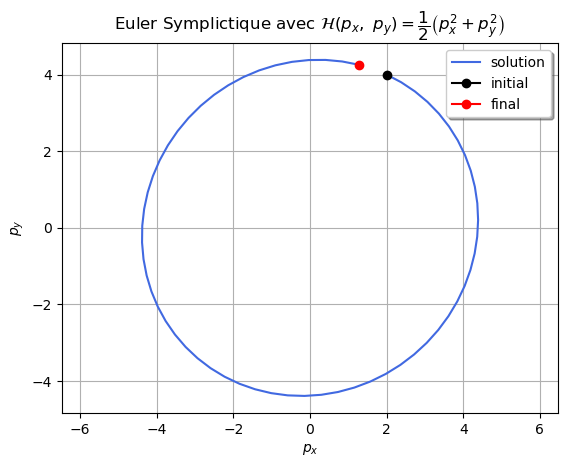

In [5]:
# Euler Symplictique -----------------------------
def ES_jouet(deltaT, T, P):
    Iteration_matrix = [[1 - deltaT**2, deltaT], [-deltaT, 1]]
    N = int(np.floor(T/deltaT))
    P_trajectory = np.zeros((N, 2))
    P_trajectory[0] = P
    for i in range(1,N):
        P = Iteration_matrix @ P_trajectory[i-1]
        P_trajectory[i] = P
    return P_trajectory
# -----------------------------------------------
p_x, p_y = 2, 4
P = np.array([p_x, p_y])
deltaT = 0.1
T = 2 * np.pi
P_trajectory = ES_jouet(deltaT, T, P)

plt.plot(P_trajectory[:, 0], P_trajectory[:,1], color='royalblue',label='solution')
plt.plot(P_trajectory[0,0], P_trajectory[0, 1], color='black', marker='o', label='initial')
plt.plot(P_trajectory[-1,0], P_trajectory[-1, 1], color='red', marker='o', label='final')

plt.legend(shadow=True)
plt.title(r'Euler Symplictique avec $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$ ')
plt.grid()
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.axis('equal')
plt.show()

### Comparaison des 3 méthodes



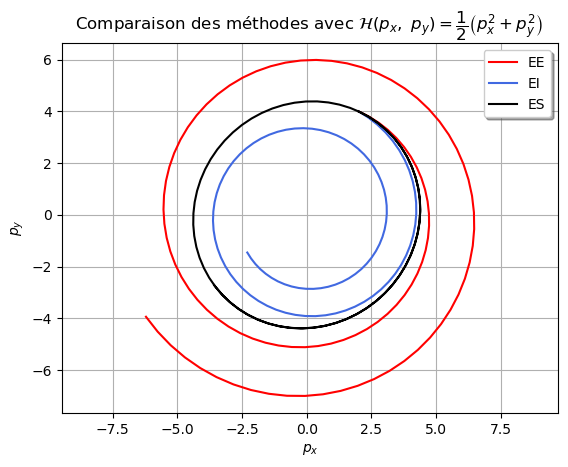

In [6]:
p_x, p_y = 2, 4
P = np.array([p_x, p_y])
deltaT = 0.1
T = 10
#---- Trajectoires selon les méthodes
traj_EX = EE_jouet(deltaT, T, P)
plt.plot(traj_EX[:, 0], traj_EX[:,1], color='red',label='EE')

traj_EI = EI_jouet(deltaT, T, P)
plt.plot(traj_EI[:, 0], traj_EI[:,1], color='royalblue',label='EI')

traj_ES = ES_jouet(deltaT, T, P)
plt.plot(traj_ES[:, 0], traj_ES[:,1], color='black',label='ES')

plt.legend(shadow=True)
plt.grid()
plt.title(r'Comparaison des méthodes avec $\mathcal{H}(p_x, \ p_y) = \dfrac{1}{2}\left(p_x^2 + p_y^2\right)$ ')
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.axis('equal')
plt.show()

## Étude du pas
On s'interrese à la taille du pas necessaire pour vérifier un certain seuil d'erreur.

Comme dans le cas Bande parabolique, on peut calculer la solution théorique de notre problème, ici on trouve la solution :
$$
\begin{cases}
p_x(t) = \cos(t) \\
p_y(t) = -\sin(t)
\end{cases}
$$

Si l'on pose $\theta \leq 10^{-6} $ notre seuil d'erreur on s'intéresse alors à:
$$
\lVert S_{\Delta t} - S_{ex} \rVert_{L^{\infty}} \leq \theta
$$
Où S désigne la solution approché en fonction de du pas ou la solution exacte selon la notation.
Avec un développement limité sur $p_x(t + \Delta t)$ on obtient pour chaque pas de temps:
$$
\left \lVert \dfrac{(\Delta t)^2}{2} \times p''_x(t) \right \rVert_{L^{\infty}}\leq \theta
$$
En posant $T$ le temps final, l'erreur globale devient alors:
$$
\dfrac{T}{\Delta t} \times \dfrac{(\Delta t)^2}{2} \times \left \lVert p''_x(t) \right \rVert_{L^{\infty}} \leq \theta
$$

D'où (et c'est la même chose pour $p_y$) :
$$
\Delta t \leq \dfrac{2 \theta}{T \left \lVert p''_x(t) \right \rVert_{L^{\infty}}} = \dfrac{2 \theta}{T}
$$


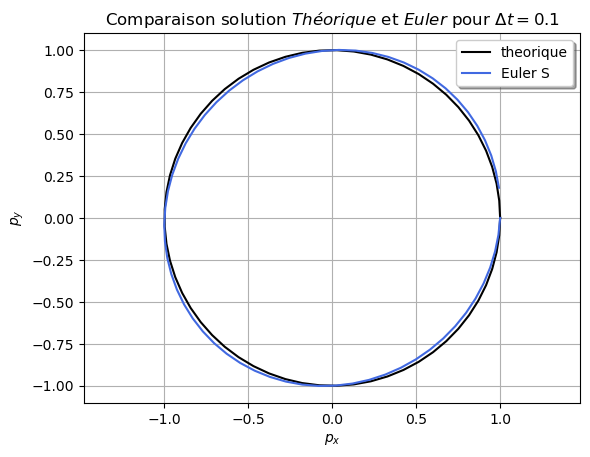

L'erreur Linf obtenue est alors de : 0.1798849578242939
L'erreur L2 obtenue est alors de : 0.2171982503648836


In [7]:
def theorique(t):
    px = np.cos(t)
    py = -np.sin(t)
    sol = np.zeros((len(t), 2))
    sol[:,0]= px
    sol[:,1] = py
    return sol

def Err_Linf(f1, f2):
    return np.max(np.abs(f1 - f2))
def Err_L2(f1, f2):
    return np.sqrt(np.sum(deltaT * np.abs(f1-f2)**2))

deltaT = 0.1
T = 2 * np.pi
N = int(np.floor(T / deltaT))
time_range = np.linspace(0, T, N)
P = np.array([1,0])

sol_ES = ES_jouet(deltaT, T, P)
sol_theo = theorique(time_range)

plt.figure()
plt.plot(sol_theo[:, 0], sol_theo[:, 1], color='black', label='theorique')
plt.plot(sol_ES[:, 0], sol_ES[:, 1], color='royalblue', label='Euler S')
plt.legend(shadow=True)
plt.grid()
plt.title(fr'Comparaison solution $Théorique$ et $Euler$ pour $\Delta t = {deltaT}$')
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_y$')
plt.axis('equal')
plt.show()

errLinf = Err_Linf(sol_ES, sol_theo)
errL2 = Err_L2(sol_ES, sol_theo)
print(f'L\'erreur Linf obtenue est alors de : {errLinf}')
print(f'L\'erreur L2 obtenue est alors de : {errL2}')


On peut alors regarder la pente des erreurs en fonction du pas de temps pour se faire une meilleure idée.

        Computation finished in 0 seconds
        Computation finished in 0 seconds
        Computation finished in 0 seconds
        Computation finished in 0 seconds


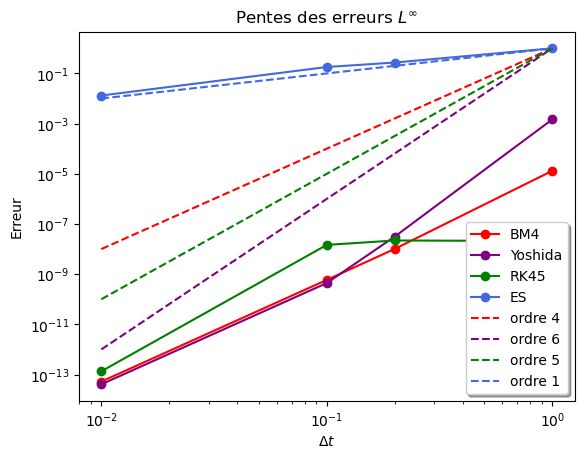

In [76]:
deltaT_tab = np.array([ 1E-2, 1E-1 , 2E-1, 1E0]) # 1E-3, 2E-3, 1E-2, 

T = 2 * np.pi
def jouet_system(t, P): #resolution papier pour bande parabolique
    
    return np.array( [ P[1], -P[0] ])

Erreur_sol_BM4 = []
Erreur_sol_Yoshida = []
Erreur_sol_ES = []
Erreur_sol_RK45 = []

hs = HamSys(ndof=1)
for i, deltaT in enumerate(deltaT_tab):

    time_range = np.linspace(0, T , int(T / deltaT)) 
    hs.y_dot = jouet_system # choix du système

    # --- Calcul des solutions ------------------------------------------------------------------------------------------------
    sol_BM4 = solve_ivp_sympext(hs, t_span=(0,T ), t_eval=time_range, y0=P, params=Parameters(step=deltaT, solver='BM4',))
    # sol_Verlet = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Verlet')).y[1]
    sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), t_eval=time_range, y0=P, params=Parameters(step=deltaT, solver='Yos6'))
    Moment_ES = ES_jouet(deltaT, T, P)
    sol_RK45 = hs.integrate( P, time_range, params=Parameters(step=deltaT, solver='RK45'))
    sol_theorique = theorique(time_range)

    # --------------------------------------------------------------------------
    # print(f'THéorique = {np.round(sol_theorique,4)}')
    # print(f'BM4 = {np.round(sol_BM4,4)}')
    # print(f'ES = {np.round(Moment_ES,4)}')
    # print(f'Yoshida = {np.round(sol_Yoshida,4)}')
    # print(f'RK4 = {np.round(sol_RK45,4)}')

    # --- Calcul des erreurs ---------------------------------------------------------------------------------------------------
    Erreur_sol_BM4.append(Err_Linf(sol_theorique[:, 1], sol_BM4.y[1]))
    Erreur_sol_Yoshida.append(Err_Linf(sol_theorique[:, 1], sol_Yoshida.y[1]))
    Erreur_sol_ES.append(Err_Linf(sol_theorique[:, 1], Moment_ES[:,1]))
    Erreur_sol_RK45.append(Err_Linf(sol_theorique[:, 1], sol_RK45.y[1]))

plt.figure()
plt.loglog(deltaT_tab, Erreur_sol_BM4, marker='o', label='BM4', color='red')
plt.loglog(deltaT_tab, Erreur_sol_Yoshida, marker='o', label='Yoshida', color='purple')
plt.loglog(deltaT_tab, Erreur_sol_RK45, marker='o', label='RK45', color='green')
plt.loglog(deltaT_tab, Erreur_sol_ES, marker='o', label='ES', color='royalblue')

plt.loglog(deltaT_tab,  deltaT_tab**4 , linestyle='--', color='red', label='ordre 4')
plt.loglog(deltaT_tab,  deltaT_tab**6, linestyle='--', color='purple', label='ordre 6')
plt.loglog(deltaT_tab,  deltaT_tab**5, linestyle='--', color='green', label='ordre 5')
plt.loglog(deltaT_tab, deltaT_tab, linestyle='--', color='royalblue', label='ordre 1')

plt.legend(shadow=True)
plt.title(r'Pentes des erreurs $L^\infty$')
plt.xlabel(r'$\Delta t$')
plt.ylabel('Erreur')
plt.show()
# --------- Pour adapter le maillage pour le delta T plus tard
Const_Yoshida = np.mean(  np.array(Erreur_sol_Yoshida)[:] / (deltaT_tab[:]**6 * T) )
Const_RK45 = np.mean(  np.array(Erreur_sol_RK45)[:] / (deltaT_tab[:]**5 * T) )

# ----------- PENTES AVEC ERREUR L2 (on recalcule les solutions c'est pas optimisé)---------------------------------------

# Le résultat étant identique je ne l'affiche pas

# Erreur_sol_BM4 = []
# Erreur_sol_Yoshida = []
# Erreur_sol_ES = []
# Erreur_sol_RK45 = []

# hs = HamSys(ndof=1)
# for i, deltaT in enumerate(deltaT_tab):

#     time_range = np.linspace(0, T , int(T / deltaT)) 
#     hs.y_dot = jouet_system # choix du système

#     # --- Calcul des solutions ------------------------------------------------------------------------------------------------
#     sol_BM4 = solve_ivp_sympext(hs, t_span=(0,T ), t_eval=time_range, y0=P, params=Parameters(step=deltaT, solver='BM4',))
#     # sol_Verlet = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Verlet')).y[1]
#     sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), t_eval=time_range, y0=P, params=Parameters(step=deltaT, solver='Yos6'))
#     Moment_ES = ES_jouet(deltaT, T, P)
#     sol_RK45 = hs.integrate( P, time_range, params=Parameters(step=deltaT, solver='RK45'))
#     sol_theorique = theorique(time_range)

#     # --------------------------------------------------------------------------
#     # print(f'THéorique = {np.round(sol_theorique,4)}')
#     # print(f'BM4 = {np.round(sol_BM4,4)}')
#     # print(f'ES = {np.round(Moment_ES,4)}')
#     # print(f'Yoshida = {np.round(sol_Yoshida,4)}')
#     # print(f'RK4 = {np.round(sol_RK45,4)}')

#     # --- Calcul des erreurs ---------------------------------------------------------------------------------------------------
#     Erreur_sol_BM4.append(Err_L2(sol_theorique[:, 1], sol_BM4.y[1]))
#     Erreur_sol_Yoshida.append(Err_L2(sol_theorique[:, 1], sol_Yoshida.y[1]))
#     Erreur_sol_ES.append(Err_L2(sol_theorique[:, 1], Moment_ES[:,1]))
#     Erreur_sol_RK45.append(Err_L2(sol_theorique[:, 1], sol_RK45.y[1]))

# plt.figure()
# plt.loglog(deltaT_tab, Erreur_sol_BM4, marker='o', label='BM4', color='red')
# plt.loglog(deltaT_tab, Erreur_sol_Yoshida, marker='o', label='Yoshida', color='purple')
# plt.loglog(deltaT_tab, Erreur_sol_RK45, marker='o', label='RK45', color='green')
# plt.loglog(deltaT_tab, Erreur_sol_ES, marker='o', label='ES', color='royalblue')

# plt.loglog(deltaT_tab,  deltaT_tab**4 , linestyle='--', color='red', label='ordre 4')
# plt.loglog(deltaT_tab,  deltaT_tab**6, linestyle='--', color='purple', label='ordre 6')
# plt.loglog(deltaT_tab,  deltaT_tab**5, linestyle='--', color='green', label='ordre 5')
# plt.loglog(deltaT_tab, deltaT_tab, linestyle='--', color='royalblue', label='ordre 1')

# plt.legend(shadow=True)
# plt.title(r'Pentes des erreurs $L^2$')
# plt.xlabel(r'$\Delta t$')
# plt.ylabel('Erreur')
# plt.show()



On s'interresse maintenant au pas nécessaire pour vérifier un certain seuil d'erreur.

In [61]:
err = 10**(-5)
print(f'On fixe le seuil à : {err}\n')
T = 2 * np.pi 
vd=0.3

def varepsilon(P):
   return (P[0]**2 + P[1]**2) / 2 # J'ai pris le même que pour le cas parabolique avec alpha=1
def W(P):
   return varepsilon(P) + vd * P[1]

# ----------------------------------------------------------------------------
deltaT_ES = 2 * err / T

time_range = np.linspace(0, T , int(T / deltaT_ES)) 

start = time.perf_counter()
Moment_ES = ES_jouet(deltaT_ES, T, P)
end = time.perf_counter()
time_ES = end - start

sol_theorique = theorique(time_range)

Erreur_sol_ES = Err_Linf(sol_theorique[:, 1], Moment_ES[:,1])

W0 = W(P)
Wf = W([Moment_ES[-1,0], Moment_ES[-1, 1]])
# --- NORME L2 SUR P''_x(t) dans l'écriture du seuil ---------------------------
# deltaT_ES_norm2 = 2 * err / (T * np.linalg.norm(sol_theorique[:, 0]))
# time_range = np.linspace(0, T , int(T / deltaT_ES_norm2)) 
# Moment_ES_L2 = ES_jouet(deltaT_ES_norm2, T, P)
# sol_theorique_L2 = theorique(time_range)
# Erreur_sol_ES_L2 = Err_Linf(sol_theorique_L2[:, 1], Moment_ES_L2[:,1])

print(f''' Schéma ES
      Pas de temps: {deltaT_ES}
      Erreur schéma ES : {Erreur_sol_ES}
      temps total pour execution de ES : {time_ES}
      Difference energie entre le debut et la fin = : {np.abs(W0 - Wf)}
''')

# --------------------------------------------------------------------------------

hs.y_dot = jouet_system # choix du système
deltaT = ( err / (T * Const_Yoshida))**(1/6)
time_range_yoshida = np.linspace(0, T, int(T/deltaT))

sol_theorique = theorique(time_range_yoshida)

start = time.perf_counter()
sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), t_eval=time_range_yoshida, y0=P, params=Parameters(step=deltaT, solver='Yos6'))
end = time.perf_counter()
time_Yoshida = end - start

Erreur_sol_Yoshida = Err_Linf(sol_theorique[:, 1], sol_Yoshida.y[1])
W0 = W(P)
Wf = W([sol_Yoshida.y[0][-1], sol_Yoshida.y[1][-1]])

print(f''' Solver Yoshida 
      Pas de temps: {deltaT}
      Erreur schéma Yoshida : {Erreur_sol_Yoshida}
      temps total pour execution de Yoshida : {time_Yoshida}
      Difference energie entre le debut et la fin = : {np.abs(W0 - Wf)}
''')
# --- RK45 ------------------------------------------------------------------
deltaT = ( err / (T * Const_RK45))**(1/5)
time_range_RK45= np.linspace(0, T, int(T/deltaT))

sol_theorique = theorique(time_range_RK45)

start = time.perf_counter()
sol_RK45 = solve_ivp_sympext(hs, t_span=(0,T), t_eval=time_range_RK45, y0=P, params=Parameters(step=deltaT, solver='Yos6'))
end = time.perf_counter()
time_RK45 = end - start

Erreur_sol_RK45 = Err_Linf(sol_theorique[:, 1], sol_RK45.y[1])
W0 = W(P)
Wf = W([sol_RK45.y[0][-1], sol_RK45.y[1][-1]])

print(f''' Solver RK45
      Pas de temps: {deltaT}
      Erreur schéma RK45 : {Erreur_sol_RK45}
      temps total pour execution de RK45 : {time_RK45}
      Difference energie entre le debut et la fin = : {np.abs(W0 - Wf)}
''')

# ------------- Estimation Temps de Calcul ---------------------------
def print_total_time(err, T_final):
      N = 1E4
      # time_range = np.linspace(0, T , N)
      deltaT_ES = 2 * err / T_final
      n_tests = 10
      times = []
      for _ in range(n_tests):
            start = time.perf_counter()
            ES_jouet(deltaT_ES, deltaT_ES * N, P)
            end = time.perf_counter()
            times.append((end - start) / N)
      time_pas_ES = np.median(times) # median évite les temps trop élevé qui change la moyenne

      N_ES = int(np.floor(T_final**2 / (2 * err))) 
      # ---- Yoshida -------------------------------------------------------
      N = 3
      deltaT_yoshida = err / (Const_Yoshida * T_final)

      start = time.perf_counter()
      solve_ivp_sympext(hs, t_span=(0,N * deltaT_yoshida), t_eval=np.linspace(0, deltaT_yoshida * N, N), y0=P, params=Parameters(step=deltaT_yoshida, solver='Yos6'))
      end = time.perf_counter()
      time_pas_Yoshida = (end - start) / N
      N_Yoshida = int(np.floor(T_final * (T_final * Const_Yoshida / err)**(1/6)))
      # ------ Affichage --------------------------------------------------
      # ES 
      if np.round(N_ES * time_pas_ES, 3) < 60:
            print(f'''Estimation du temps pour seuil err = {err}
            ES temps estimé : {np.round(N_ES * time_pas_ES, 2)} secondes
             ''')
      elif np.round(N_ES * time_pas_ES, 3) < 60 * 60:
           print(f'''Estimation du temps pour seuil err = {err}
            ES temps estimé : {np.round(N_ES * time_pas_ES / 60, 2)} minutes
             ''')
      elif np.round(N_ES * time_pas_ES, 3) < 60 * 60 *24:
           print(f'''Estimation du temps pour seuil err = {err}
            ES temps estimé : {np.round(N_ES * time_pas_ES / (60*60), 2)} heures
             ''')
      elif np.round(N_ES * time_pas_ES, 3) < 60 * 60 * 24 * 365 :
           print(f'''Estimation du temps pour seuil err = {err}
            ES temps estimé : {np.round(N_ES * time_pas_ES / (60*60*24), 2)} jours
             ''')
      else:
           print(f'''Estimation du temps pour seuil err = {err}
            ES temps estimé : {np.round(N_ES * time_pas_ES / (60*60*24*365), 2)} années
             ''')
           
      # Yoshida
      if np.round(N_Yoshida* time_pas_Yoshida, 3) < 60:
            print(f'''        Yoshida temps estimé : {np.round(N_Yoshida* time_pas_Yoshida, 2)} secondes
                  ''')
      elif np.round(N_Yoshida* time_pas_Yoshida, 3) < 60 * 60:
            print(f'''        Yoshida temps estimé : {np.round(N_Yoshida * time_pas_Yoshida / 60, 2)} minutes
                  ''')
      elif np.round(N_Yoshida* time_pas_Yoshida, 3) < 60 * 60 *24:
            print(f'''        ES temps estimé : {np.round(N_Yoshida* time_pas_Yoshida / (60*60), 2)} heures
                  ''')
      elif np.round(N_Yoshida* time_pas_Yoshida, 3) < 60 * 60 *24 * 365:
           print(f'''         ES temps estimé : {np.round(N_Yoshida* time_pas_Yoshida / (60*60*24), 2)} jours
             ''')
      else:
           print(f'''         ES temps estimé : {np.round(N_Yoshida * time_pas_Yoshida / (60*60*24*365), 2)} années
             ''')
      


On fixe le seuil à : 1e-05

 Schéma ES
      Pas de temps: 3.183098861837907e-06
      Erreur schéma ES : 5.984916706147622e-06
      temps total pour execution de ES : 5.961926299962215
      Difference energie entre le debut et la fin = : 1.7954854488744232e-06

 Solver Yoshida 
      Pas de temps: 0.31242819262231714
      Erreur schéma Yoshida : 4.84097208849191e-07
      temps total pour execution de Yoshida : 0.010218699928373098
      Difference energie entre le debut et la fin = : 1.452291609194134e-07

 Solver RK45
      Pas de temps: 0.4252717682371244
      Erreur schéma RK45 : 4.721622221574143e-06
      temps total pour execution de RK45 : 0.007648700033314526
      Difference energie entre le debut et la fin = : 1.4164865473897947e-06



### On peut aussi estimer à l'avance le temps de calcul.
Sur l'exemple précédent on a vu que pour atteindre une précision de l'ordre de 10^-5 on aurait besoin de 5 secondes avec notre schéma. En simulant le temps pris pour calculer les première itérations on peut estimer le temps total nécessaire pour calculer la solution.

In [75]:
print_total_time(1e-5, T)

print_total_time(1e-13, T)

Estimation du temps pour seuil err = 1e-05
            ES temps estimé : 5.52 secondes
             
        Yoshida temps estimé : 0.01 secondes
                  
Estimation du temps pour seuil err = 1e-13
            ES temps estimé : 17.97 années
             
        Yoshida temps estimé : 0.17 secondes
                  
